In [6]:
# Kullanacağım kütüphaneleri çağırıyorum
import pandas as pd
import matplotlib.pyplot as plt

# Grafik ayarları
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.figsize"] = (10, 5)

# Dosyayı yükleme
from google.colab import files
yuklenen = files.upload()
dosya_adi = list(yuklenen.keys())[0]

# CSV dosyasını okuma
df = pd.read_csv(
    dosya_adi,
    sep=",",
    decimal=".",
    encoding="utf-8-sig"
)

# Veri kontrolü
print("Veri Bilgisi:")
print(f"Satır Sayısı: {df.shape[0]}")
print(f"Sütunlar: {df.columns.tolist()}")
df.head()

Saving Başlıksız e-tablo - turkiye_tutun_ticaret_2021_2025.csv to Başlıksız e-tablo - turkiye_tutun_ticaret_2021_2025 (2).csv
Veri Bilgisi:
Satır Sayısı: 30
Sütunlar: ['YIL', 'TICARET_TURU', 'GTIP_KODU', 'URUN_GRUBU', 'MIKTAR_KG', 'DEGER_USD', 'MIKTAR_TON', 'DEGER_MILYON']


,YIL,TICARET_TURU,GTIP_KODU,URUN_GRUBU,MIKTAR_KG,DEGER_USD,MIKTAR_TON,DEGER_MILYON
0,2021,Ithalat,2401,"Tobacco, unmanufactured; tobacco refuse","74.417.857,00","342.040.710,00","74.417,86","342,04"
1,2021,Ithalat,2402,"Cigars, cheroots, cigarillos and cigarettes; o...","2.777.052,00","133.973.790,00","2.777,05","133,97"
2,2021,Ithalat,2403,Manufactured tobacco and manufactured tobacco ...,"26.518.723,00","167.833.527,00","26.518,72","167,83"
3,2021,Ihracat,2401,"Tobacco, unmanufactured; tobacco refuse","51.691.085,00","260.941.693,00","51.691,09","260,94"
4,2021,Ihracat,2402,"Cigars, cheroots, cigarillos and cigarettes; o...","37.311.977,00","342.236.355,00","37.311,98","342,24"


In [7]:
# Eksik veri var mı bakıyorum
print("Eksik veri sayısı:")
print(df.isnull().sum())

# Sütun isimlerini küçük harfe çeviriyorum
df.columns = [col.lower() for col in df.columns]

# Değerleri kontrol ediyorum
print("\nTicaret türü sınıfları:")
print(df["ticaret_turu"].unique())
print("\nÜrün grupları:")
print(df["urun_grubu"].unique())

Eksik veri sayısı:
YIL             0
TICARET_TURU    0
GTIP_KODU       0
URUN_GRUBU      0
MIKTAR_KG       0
DEGER_USD       0
MIKTAR_TON      0
DEGER_MILYON    0
dtype: int64

Ticaret türü sınıfları:
['Ithalat' 'Ihracat']

Ürün grupları:
['Tobacco, unmanufactured; tobacco refuse'
 'Cigars, cheroots, cigarillos and cigarettes; of tobacco or of tobacco substitutes'
 'Manufactured tobacco and manufactured tobacco substitutes n.e.c; homogenised or reconstituted tobacco; tobacco extracts and essences']


In [16]:
# ----------------------
# 3. Ürün adlarını sadeleştir ve hesaplamalar
# ----------------------

# Sütun isimlerini düzenle
df.columns = df.columns.str.strip().str.upper()

# ✅ Binlik noktayı sil, ondalık virgülü noktaya çevir
def sayiya_cevir(deger):
    if pd.isna(deger):
        return 0.0
    # Önce binlik ayırıcı olan noktayı sil
    deger = str(deger).replace(".", "")
    # Sonra ondalık ayırıcı virgülü noktaya çevir
    deger = deger.replace(",", ".")
    return float(deger)

# Tüm sayısal sütunlara uygula
df["MIKTAR_KG"] = df["MIKTAR_KG"].apply(sayiya_cevir)
df["DEGER_USD"] = df["DEGER_USD"].apply(sayiya_cevir)
df["MIKTAR_TON"] = df["MIKTAR_TON"].apply(sayiya_cevir)
df["DEGER_MILYON"] = df["DEGER_MILYON"].apply(sayiya_cevir)

# Ticaret türü değerlerini temizle
df["TICARET_TURU"] = df["TICARET_TURU"].str.strip()

# Ürün isimlerini kısalt
df["URUN_GRUBU"] = df["URUN_GRUBU"].replace({
    "Tobacco, unmanufactured, tobacco refuse": "Ham Tütün",
    "Cigars, cheroots, cigarillos and cigarettes; of tobacco or of tobacco substitutes": "Sigara ve Puro",
    "Manufactured tobacco and manufactured tobacco substitutes n.e.c; homogenised or reconstituted tobacco; tobacco extracts and essences": "İşlenmiş Tütün"
})

# Yıllara göre toplam hesaplama
toplam = df.groupby(["YIL", "TICARET_TURU"], as_index=False)["DEGER_MILYON"].sum()
print("Yıllık Toplam Ticaret Hacmi (Milyon USD):")
print(toplam.round(2))

# Ticaret dengesi hesaplama
ithalat = df[df["TICARET_TURU"] == "Ithalat"].groupby("YIL")["DEGER_MILYON"].sum()
ihracat = df[df["TICARET_TURU"] == "Ihracat"].groupby("YIL")["DEGER_MILYON"].sum()

denge = pd.DataFrame({
    "YIL": ithalat.index,
    "ITHALAT_MILYON": ithalat.values.round(2),
    "IHRACAT_MILYON": ihracat.values.round(2)
})

denge["TICARET_DENGESI"] = denge["ITHALAT_MILYON"] - denge["IHRACAT_MILYON"]

print("Ticaret Dengesi (Milyon USD):")
print(denge)

Yıllık Toplam Ticaret Hacmi (Milyon USD):
    YIL TICARET_TURU  DEGER_MILYON
0  2021      Ihracat       62103.0
1  2021      Ithalat       64384.0
2  2022      Ihracat       84105.0
3  2022      Ithalat       75140.0
4  2023      Ihracat       93282.0
5  2023      Ithalat       51690.0
6  2024      Ihracat       99068.0
7  2024      Ithalat      104731.0
8  2025      Ihracat      107140.0
9  2025      Ithalat       94234.0
Ticaret Dengesi (Milyon USD):
    YIL  ITHALAT_MILYON  IHRACAT_MILYON  TICARET_DENGESI
0  2021         64384.0         62103.0           2281.0
1  2022         75140.0         84105.0          -8965.0
2  2023         51690.0         93282.0         -41592.0
3  2024        104731.0         99068.0           5663.0
4  2025         94234.0        107140.0         -12906.0


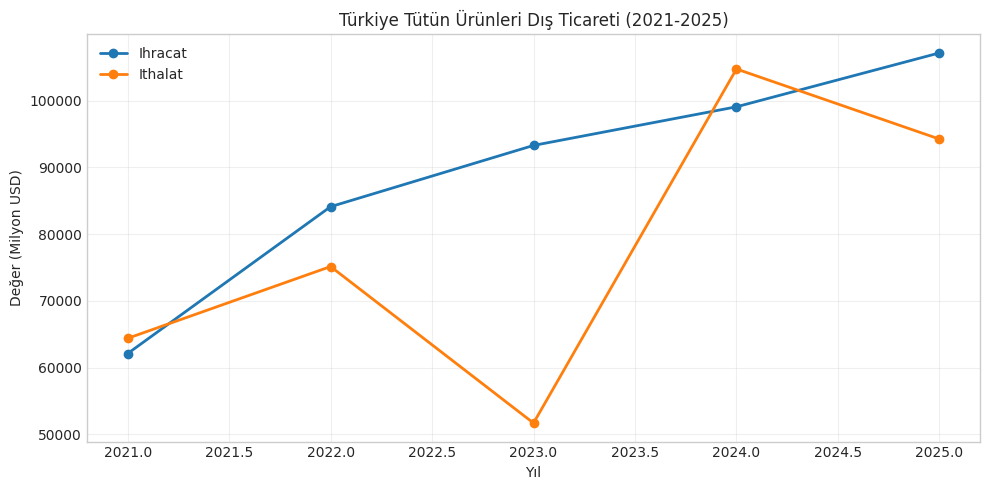

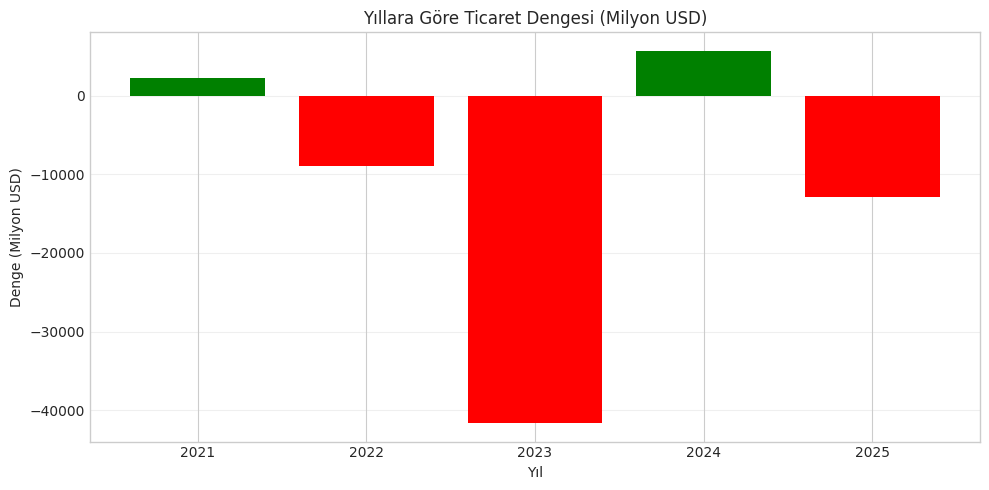

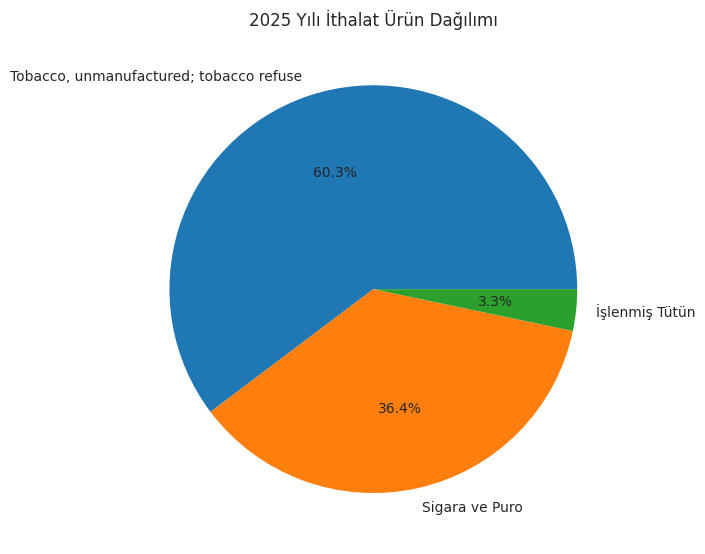

In [17]:
# Grafik ayarları
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.figsize"] = (10, 5)

# 1. Yıllara Göre İthalat - İhracat Trendi
plt.figure()
for tur in toplam["TICARET_TURU"].unique():
    veri = toplam[toplam["TICARET_TURU"] == tur]
    plt.plot(veri["YIL"], veri["DEGER_MILYON"], marker="o", linewidth=2, label=tur)

plt.title("Türkiye Tütün Ürünleri Dış Ticareti (2021-2025)")
plt.xlabel("Yıl")
plt.ylabel("Değer (Milyon USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Ticaret Dengesi Grafiği
plt.figure()
plt.bar(denge["YIL"], denge["TICARET_DENGESI"], color=["red" if x < 0 else "green" for x in denge["TICARET_DENGESI"]])
plt.title("Yıllara Göre Ticaret Dengesi (Milyon USD)")
plt.xlabel("Yıl")
plt.ylabel("Denge (Milyon USD)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 3. 2025 Yılı Ürün Dağılımı
veri_2025 = df[(df["YIL"] == 2025) & (df["TICARET_TURU"] == "Ithalat")]
plt.figure(figsize=(7, 7))
plt.pie(veri_2025["DEGER_MILYON"], labels=veri_2025["URUN_GRUBU"], autopct="%1.1f%%")
plt.title("2025 Yılı İthalat Ürün Dağılımı")
plt.tight_layout()
plt.show()

In [18]:
# Son halini kaydedip indiriyorum
df.to_csv("tutun_ticaret_analiz_son.csv", index=False, encoding="utf-8-sig")
files.download("tutun_ticaret_analiz_son.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>